In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.preprocessing import PolynomialFeatures

In [9]:
df=pd.read_csv("ushape.csv",header=None)

In [11]:
df.columns=["x","y","class"]

In [12]:
df

,x,y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0
...,...,...,...
95,1.699453,0.587720,1.0
96,0.218623,-0.652521,1.0
97,0.952914,-0.419766,1.0
98,-1.318500,0.423112,0.0


In [14]:
x=df.iloc[:,:2].values
y=df.iloc[:,-1].values

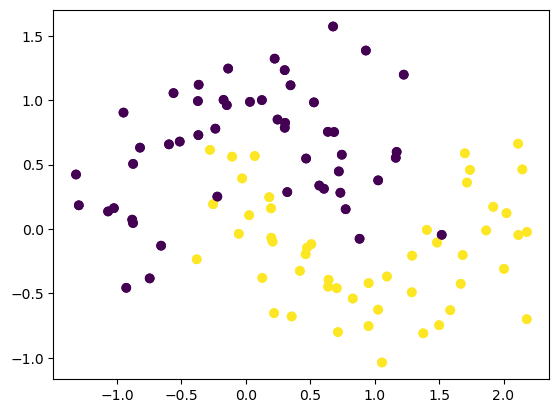

In [17]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()

In [19]:
LR.fit(x,y)

LogisticRegression()

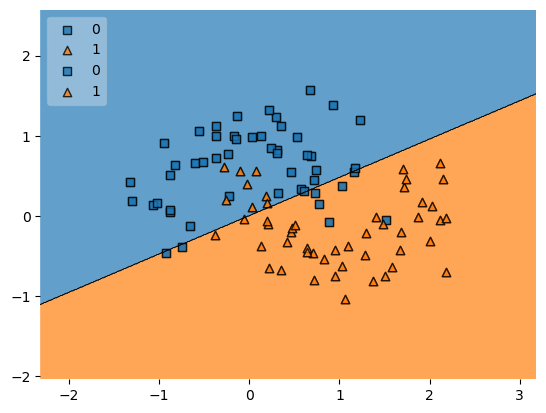

In [21]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x,y.astype('int'),LR,legend=2)
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score
print(np.mean(cross_val_score(LR,x,y,scoring="accuracy",cv=10)))

0.8300000000000001


In [29]:
PF=PolynomialFeatures(degree=2,include_bias=False)
x_trans=PF.fit_transform(x)

In [30]:
clf=LogisticRegression()
print(np.mean(cross_val_score(clf,x_trans,y,scoring="accuracy",cv=10)))

0.8300000000000001


In [33]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))
    plt.show()

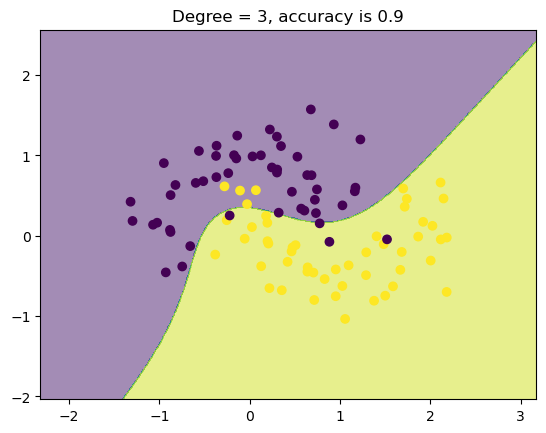

In [38]:
plot_decision_boundary(x,y,degree=3)